# Si [100] Unit-Cell Verification: Multislice vs WPM vs Wave ODE

Static silicon conventional-unit-cell thickness sweep comparing five propagation methods.

**Methods**: Fresnel (Paraxial), Angular Spectrum (Non-Paraxial), WPM, Second-Order Wave ODE, Forward Square-Root Propagator

**Crystal**: Si diamond cubic conventional cell from `notebooks/data/Si.cif`, beam along the cubic z axis, no thermal motion.

**Potential**: Lobato parametrization for all methods. This avoids reusing the Au-only Weickenmeier-Kohl helper from the Au notebook for silicon.

**Default run**: validation mode uses the verified Si cell with 128x128 lateral sampling, 128 slices/cell, and 0-3 unit cells so every method can be run interactively with the same z-sampling rigor as the Au notebook. Set `RUN_FULL = True` in the parameters cell for 0-100 unit cells.

In [37]:
%matplotlib inline

import os
from pathlib import Path
from time import perf_counter

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".2"

import abtem
import cupy
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from ase import Atoms
from ase.build import bulk
from ase.io import read as read_atoms
from tqdm.auto import tqdm

from wide_angle_propagation.propagation_methods import (
    angular_spectrum_propagation_kernel,
    beam_amplitudes_fwd_direct_allbeams,
    energy2wavelength,
    fresnel_propagation_kernel,
    simulate_fresnel_as,
    simulate_kg_ode_full,
    simulate_wpm,
)

abtem.config.set({"device": "gpu"})
abtem.config.set({"precision": "float64"})
jax.config.update("jax_enable_x64", True)


def find_repo_root():
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        if (base / "notebooks" / "data" / "Si.cif").exists():
            return base
    raise FileNotFoundError("Could not locate notebooks/data/Si.cif from current working directory")


def sorted_fractional_rows(frac):
    frac = np.mod(np.asarray(frac, dtype=float), 1.0)
    frac[np.isclose(frac, 1.0, atol=1e-10)] = 0.0
    rounded = np.round(frac, 10)
    order = np.lexsort((rounded[:, 2], rounded[:, 1], rounded[:, 0]))
    return rounded[order]


def beam_amplitude_normalized(psi_xy, h, k, use_fftshift=True):
    ny, nx = psi_xy.shape
    coeffs = np.fft.fft2(psi_xy) / (nx * ny)
    if use_fftshift:
        coeffs = np.fft.fftshift(coeffs)
        cy, cx = ny // 2, nx // 2
        return float(np.abs(coeffs[cy + k, cx + h]))
    return float(np.abs(coeffs[k % ny, h % nx]))


def curve_rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))


repo_root = find_repo_root()
print(f"Repository root: {repo_root}")

Repository root: /home/dl277493/Documents/Code/WideAnglePropagation


## Crystal setup and validation

The silicon cell is loaded from the project CIF and checked against the conventional diamond-cubic Si8 cell before any potentials are built.

In [38]:
RUN_FULL = True

a_si = 5.44370237
energy = 300e3
gpts = (128, 128)
target_beam = (0, 36)

if RUN_FULL:
    n_slices_per_cell = 128
    n_cells_range = range(0, 26)
    lanczos_m = 100
else:
    n_slices_per_cell = 128
    n_cells_range = range(0, 4)
    lanczos_m = 64

si_cif = repo_root / "notebooks" / "data" / "Si.cif"
assert si_cif.exists(), si_cif

atoms_from_cif = read_atoms(si_cif)
assert isinstance(atoms_from_cif, Atoms), f"Expected one Atoms object from {si_cif}, got {type(atoms_from_cif)}"
atoms = atoms_from_cif
atoms.pbc = [True, True, True]

expected_frac = np.array([
    [0.00, 0.00, 0.00],
    [0.00, 0.50, 0.50],
    [0.50, 0.00, 0.50],
    [0.50, 0.50, 0.00],
    [0.25, 0.25, 0.25],
    [0.25, 0.75, 0.75],
    [0.75, 0.25, 0.75],
    [0.75, 0.75, 0.25],
])

lengths = np.asarray(atoms.cell.lengths())
angles = np.asarray(atoms.cell.angles())
frac = atoms.get_scaled_positions(wrap=True)
bulk_ref = bulk("Si", "diamond", a=a_si, cubic=True)

assert len(atoms) == 8, f"Expected Si8 conventional cell, got {len(atoms)} atoms"
assert set(atoms.get_chemical_symbols()) == {"Si"}, atoms.get_chemical_symbols()
assert np.allclose(lengths, [a_si, a_si, a_si], rtol=0, atol=1e-5), lengths
assert np.allclose(angles, [90.0, 90.0, 90.0], rtol=0, atol=1e-8), angles
assert np.allclose(
    sorted_fractional_rows(frac),
    sorted_fractional_rows(expected_frac),
    rtol=0,
    atol=1e-8,
), sorted_fractional_rows(frac)
assert np.allclose(
    sorted_fractional_rows(frac),
    sorted_fractional_rows(bulk_ref.get_scaled_positions(wrap=True)),
    rtol=0,
    atol=1e-8,
)

atoms.info["thermal_sigma"] = 0.0
atoms.arrays["thermal_sigma"] = np.zeros(len(atoms))

cell_thickness = float(lengths[2])
slice_dz = cell_thickness / n_slices_per_cell
wavelength = float(energy2wavelength(energy))
target_angle_mrad = 1e3 * wavelength * np.hypot(*target_beam) / a_si

assert target_beam[0] < gpts[1] // 2 and target_beam[1] < gpts[0] // 2
assert np.isclose(cell_thickness, a_si, rtol=0, atol=1e-5)

print("Si conventional cell validation passed.")
print(f"CIF: {si_cif}")
print(f"Formula: Si{len(atoms)}, a = {a_si:.8f} Angstrom, angles = {angles}")
print(f"Beam direction: cubic z axis, equivalent to Si [100] by cubic symmetry")
print(f"Thermal motion: static, thermal_sigma = {atoms.info['thermal_sigma']}")
print(f"Mode: {'full' if RUN_FULL else 'validation'}")
print(f"Grid: {gpts}, slices/cell = {n_slices_per_cell}, dz = {slice_dz:.5f} Angstrom")
print(f"Thickness samples: {min(n_cells_range)}-{max(n_cells_range)} unit cells")
print(f"Energy: {energy/1e3:.0f} keV, lambda = {wavelength:.5f} Angstrom")
print(f"High-angle test beam: {target_beam}, small-angle estimate = {target_angle_mrad:.1f} mrad")

Si conventional cell validation passed.
CIF: /home/dl277493/Documents/Code/WideAnglePropagation/notebooks/data/Si.cif
Formula: Si8, a = 5.44370237 Angstrom, angles = [90. 90. 90.]
Beam direction: cubic z axis, equivalent to Si [100] by cubic symmetry
Thermal motion: static, thermal_sigma = 0.0
Mode: full
Grid: (128, 128), slices/cell = 128, dz = 0.04253 Angstrom
Thickness samples: 0-25 unit cells
Energy: 300 keV, lambda = 0.01969 Angstrom
High-angle test beam: (0, 36), small-angle estimate = 130.2 mrad


## Potential and incident wave

All methods use the same Lobato potential stack for the static silicon cell.

In [39]:
potential_si = abtem.Potential(
    atoms,
    gpts=gpts,
    slice_thickness=slice_dz,
    projection="finite",
    parametrization="lobato",
)
pot_array_si = jnp.array(cupy.asnumpy(potential_si.build(lazy=False).array / slice_dz))

assert pot_array_si.shape == (n_slices_per_cell, *gpts), pot_array_si.shape
assert np.all(np.isfinite(np.asarray(pot_array_si))), "Potential contains non-finite values"
assert float(np.max(np.asarray(pot_array_si))) > 0.0, "Potential is unexpectedly zero"

pw = abtem.PlaneWave(energy=energy)
pw.grid.match(potential_si)
psi0 = jnp.array(cupy.asnumpy(pw.build(lazy=False).array))
grid_sampling = pw.grid.sampling
assert grid_sampling is not None
sampling = (float(grid_sampling[0]), float(grid_sampling[1]))

assert psi0.shape == gpts, psi0.shape
assert np.all(np.isfinite(np.asarray(psi0))), "Plane wave contains non-finite values"

print("Potential and plane wave built.")
print(f"Potential shape: {pot_array_si.shape}, min/max = {float(pot_array_si.min()):.4e}/{float(pot_array_si.max()):.4e} V")
print(f"Sampling: ({sampling[0]:.5f}, {sampling[1]:.5f}) Angstrom/pixel")
print(f"Incident beam [0,0] amplitude: {beam_amplitude_normalized(np.asarray(psi0), 0, 0):.6f}")

Potential and plane wave built.
Potential shape: (128, 128, 128), min/max = 1.3332e+00/5.6346e+03 V
Sampling: (0.04253, 0.04253) Angstrom/pixel
Incident beam [0,0] amplitude: 1.000000


## Thickness sweep: Fresnel, angular spectrum, and WPM

In [40]:
fk = jnp.array(fresnel_propagation_kernel(*gpts, sampling, z=slice_dz, energy=energy))
ak = jnp.array(angular_spectrum_propagation_kernel(*gpts, sampling, z=slice_dz, energy=energy))

beam_results = {
    "ms_00": [],
    "ms_hi": [],
    "as_00": [],
    "as_hi": [],
    "wpm_00": [],
    "wpm_hi": [],
}

w_ms, w_as, w_wpm = psi0, psi0, psi0
t0 = perf_counter()

for i in tqdm(range(len(n_cells_range)), desc="MS/WPM sweep"):
    if i > 0:
        w_ms, _, _ = simulate_fresnel_as(pot_array_si, w_ms, fk, slice_dz, energy)
        w_as, _, _ = simulate_fresnel_as(pot_array_si, w_as, ak, slice_dz, energy)
        w_wpm, _, _ = simulate_wpm(pot_array_si, w_wpm, slice_dz, energy, sampling)
        w_ms = jnp.array(w_ms)
        w_as = jnp.array(w_as)
        w_wpm = jnp.array(w_wpm)

    beam_results["ms_00"].append(beam_amplitude_normalized(np.asarray(w_ms), 0, 0))
    beam_results["ms_hi"].append(beam_amplitude_normalized(np.asarray(w_ms), *target_beam))
    beam_results["as_00"].append(beam_amplitude_normalized(np.asarray(w_as), 0, 0))
    beam_results["as_hi"].append(beam_amplitude_normalized(np.asarray(w_as), *target_beam))
    beam_results["wpm_00"].append(beam_amplitude_normalized(np.asarray(w_wpm), 0, 0))
    beam_results["wpm_hi"].append(beam_amplitude_normalized(np.asarray(w_wpm), *target_beam))

beam_results = {key: np.asarray(value) for key, value in beam_results.items()}
ms_wpm_time = perf_counter() - t0
print(f"MS/WPM sweep complete in {ms_wpm_time:.1f}s")
print(f"Fresnel final [0,0] = {beam_results['ms_00'][-1]:.6f}, {target_beam} = {beam_results['ms_hi'][-1]:.6e}")
print(f"Angular spectrum final [0,0] = {beam_results['as_00'][-1]:.6f}, {target_beam} = {beam_results['as_hi'][-1]:.6e}")
print(f"WPM final [0,0] = {beam_results['wpm_00'][-1]:.6f}, {target_beam} = {beam_results['wpm_hi'][-1]:.6e}")

MS/WPM sweep:   0%|          | 0/26 [00:00<?, ?it/s]

MS/WPM sweep complete in 149.4s
Fresnel final [0,0] = 0.582525, (0, 36) = 7.168397e-06
Angular spectrum final [0,0] = 0.582659, (0, 36) = 1.290132e-05
WPM final [0,0] = 0.582568, (0, 36) = 1.308706e-05


## Second-Order Wave ODE thickness sweep

In [41]:
kg_ode_00, kg_ode_hi = [], []
w_kg = psi0
phi_kg = None
t0 = perf_counter()

for i in tqdm(range(len(n_cells_range)), desc="Second-Order Wave ODE sweep"):
    if i > 0:
        w_kg, phi_kg, _, _ = simulate_kg_ode_full(
            pot_array_si,
            w_kg,
            slice_dz,
            energy,
            sampling,
            initial_phi=phi_kg,
            save_wavefronts=False,
        )
        w_kg = jnp.array(w_kg)

    kg_ode_00.append(beam_amplitude_normalized(np.asarray(w_kg), 0, 0))
    kg_ode_hi.append(beam_amplitude_normalized(np.asarray(w_kg), *target_beam))

kg_ode_00 = np.asarray(kg_ode_00)
kg_ode_hi = np.asarray(kg_ode_hi)
kg_ode_time = perf_counter() - t0
print(f"Second-Order Wave ODE sweep complete in {kg_ode_time:.1f}s")
print(f"ODE final [0,0] = {kg_ode_00[-1]:.6f}, {target_beam} = {kg_ode_hi[-1]:.6e}")

Second-Order Wave ODE sweep:   0%|          | 0/26 [00:00<?, ?it/s]

Second-Order Wave ODE sweep complete in 664.8s
ODE final [0,0] = 0.582521, (0, 36) = 1.134036e-05


## Forward Square-Root Propagator thickness sweep

In [42]:
n_cells_arr = np.arange(len(n_cells_range))
t0 = perf_counter()

kg_all_amps, kg_all_bi, kg_fwd_exit_state = beam_amplitudes_fwd_direct_allbeams(
    pot_array_si,
    slice_dz,
    energy,
    sampling,
    n_cells_arr,
    gpts,
    lanczos_m=lanczos_m,
)

kg_all_00 = kg_all_amps.get((0, 0), np.zeros(len(n_cells_range)))
kg_all_hi = kg_all_amps.get(target_beam, np.zeros(len(n_cells_range)))
w_kg_fwd = gpts[0] * gpts[1] * np.fft.ifft2(kg_fwd_exit_state.reshape(gpts))
kg_fwd_time = perf_counter() - t0

print(f"Forward Square-Root Propagator sweep complete in {kg_fwd_time:.1f}s")
print(f"KG FWD final [0,0] = {kg_all_00[-1]:.6f}, {target_beam} = {kg_all_hi[-1]:.6e}")
print(f"Beams tracked: {len(kg_all_bi)}, Lanczos m = {lanczos_m}")

Forward Square-Root Propagator sweep complete in 38.5s
KG FWD final [0,0] = 0.582524, (0, 36) = 1.310951e-05
Beams tracked: 16384, Lanczos m = 100


## Comparison plots

Saved -> /home/dl277493/Documents/Code/WideAnglePropagation/notebooks/verification/figures/Si_unit_cell_beam_amplitudes_full.png


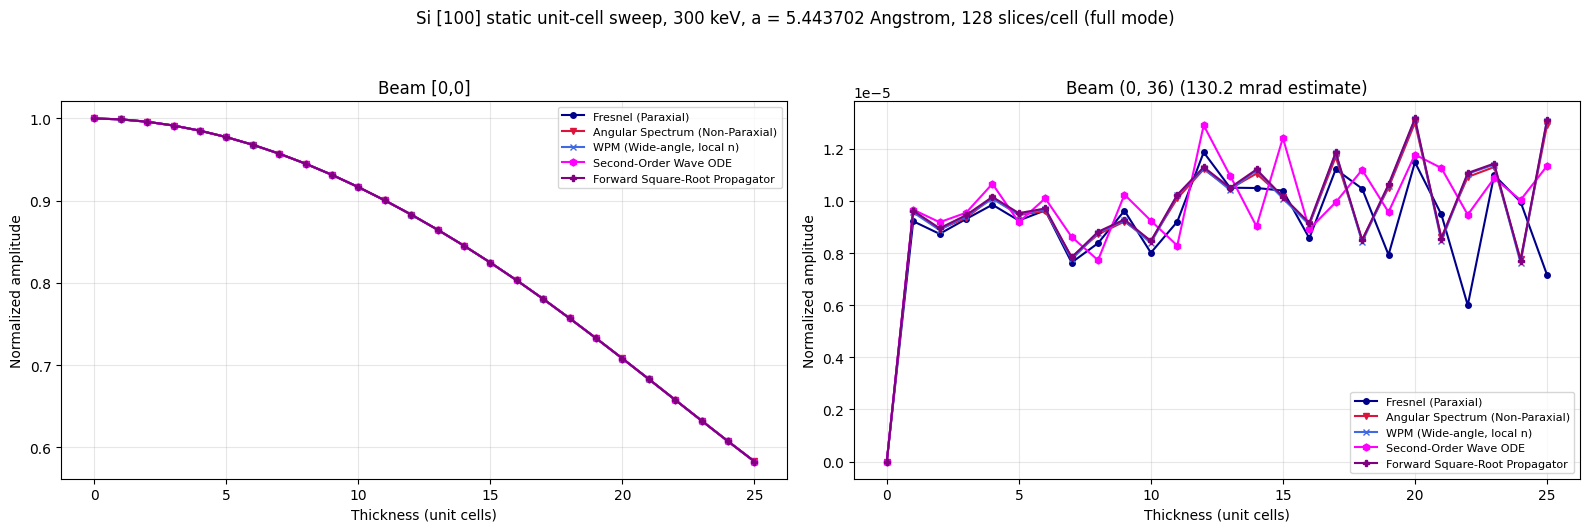

In [43]:
x = np.asarray(list(n_cells_range), dtype=float)

display_names = {
    "Fresnel MS": "Fresnel (Paraxial)",
    "Angular Spectrum MS": "Angular Spectrum (Non-Paraxial)",
    "WPM": "WPM (Wide-angle, local n)",
    "Full KG ODE": "Second-Order Wave ODE",
    "KG FWD": "Forward Square-Root Propagator",
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))

ax1.plot(x, beam_results["ms_00"], "o-", label=display_names["Fresnel MS"], color="darkblue", ms=4)
ax1.plot(x, beam_results["as_00"], "v-", label=display_names["Angular Spectrum MS"], color="crimson", ms=4)
ax1.plot(x, beam_results["wpm_00"], "x-", label=display_names["WPM"], color="royalblue", ms=5)
ax1.plot(x, kg_ode_00, "h-", label=display_names["Full KG ODE"], color="magenta", ms=5)
ax1.plot(x, kg_all_00, "P-", label=display_names["KG FWD"], color="purple", ms=4)
ax1.set_xlabel("Thickness (unit cells)")
ax1.set_ylabel("Normalized amplitude")
ax1.set_title("Beam [0,0]")
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=8)

ax2.plot(x, beam_results["ms_hi"], "o-", label=display_names["Fresnel MS"], color="darkblue", ms=4)
ax2.plot(x, beam_results["as_hi"], "v-", label=display_names["Angular Spectrum MS"], color="crimson", ms=4)
ax2.plot(x, beam_results["wpm_hi"], "x-", label=display_names["WPM"], color="royalblue", ms=5)
ax2.plot(x, kg_ode_hi, "h-", label=display_names["Full KG ODE"], color="magenta", ms=5)
ax2.plot(x, kg_all_hi, "P-", label=display_names["KG FWD"], color="purple", ms=4)
ax2.set_xlabel("Thickness (unit cells)")
ax2.set_ylabel("Normalized amplitude")
ax2.set_title(f"Beam {target_beam} ({target_angle_mrad:.1f} mrad estimate)")
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=8)

fig.suptitle(
    f"Si [100] static unit-cell sweep, {energy/1e3:.0f} keV, a = {a_si:.6f} Angstrom, "
    f"{n_slices_per_cell} slices/cell ({'full' if RUN_FULL else 'validation'} mode)",
    fontsize=12,
)
fig.tight_layout(rect=(0, 0.02, 1, 0.94))

save_dir = repo_root / "notebooks" / "verification" / "figures"
save_dir.mkdir(parents=True, exist_ok=True)
out_path = save_dir / ("Si_unit_cell_beam_amplitudes_full.png" if RUN_FULL else "Si_unit_cell_beam_amplitudes_validation.png")
fig.savefig(out_path, dpi=300, bbox_inches="tight")
print(f"Saved -> {out_path}")
plt.show()

## RMSE summary relative to the Second-Order Wave ODE

In [44]:
methods_00 = {
    "Fresnel MS": beam_results["ms_00"],
    "Angular Spectrum MS": beam_results["as_00"],
    "WPM": beam_results["wpm_00"],
    "Full KG ODE": kg_ode_00,
    "KG FWD": kg_all_00,
}
methods_hi = {
    "Fresnel MS": beam_results["ms_hi"],
    "Angular Spectrum MS": beam_results["as_hi"],
    "WPM": beam_results["wpm_hi"],
    "Full KG ODE": kg_ode_hi,
    "KG FWD": kg_all_hi,
}

print(f"RMSE computed over {min(n_cells_range)}-{max(n_cells_range)} Si unit cells, reference = Second-Order Wave ODE")
print(f"{'Method':<35s} {'[0,0] RMSE':>12s} {str(target_beam) + ' RMSE':>14s} {'Time (s)':>10s}")
print("-" * 78)
times = {
    "Fresnel MS": ms_wpm_time,
    "Angular Spectrum MS": ms_wpm_time,
    "WPM": ms_wpm_time,
    "Full KG ODE": kg_ode_time,
    "KG FWD": kg_fwd_time,
}
for name in methods_00:
    r00 = curve_rmse(methods_00[name], kg_ode_00)
    rhi = curve_rmse(methods_hi[name], kg_ode_hi)
    print(f"{display_names.get(name, name):<35s} {r00:>12.6e} {rhi:>14.6e} {times[name]:>10.1f}")

RMSE computed over 0-25 Si unit cells, reference = Second-Order Wave ODE
Method                                [0,0] RMSE   (0, 36) RMSE   Time (s)
------------------------------------------------------------------------------
Fresnel (Paraxial)                  5.126768e-05   1.396127e-06      149.4
Angular Spectrum (Non-Paraxial)     9.141024e-05   1.377431e-06      149.4
WPM (Wide-angle, local n)           5.218092e-05   1.450888e-06      149.4
Second-Order Wave ODE               0.000000e+00   0.000000e+00      664.8
Forward Square-Root Propagator      3.834655e-05   1.429935e-06       38.5


## Sanity checks

In [45]:
all_curves = [
    *beam_results.values(),
    kg_ode_00,
    kg_ode_hi,
    kg_all_00,
    kg_all_hi,
]
for curve in all_curves:
    assert np.all(np.isfinite(curve)), "Non-finite amplitude detected"
    assert np.all(curve >= 0), "Negative amplitude detected"

assert np.isclose(kg_ode_00[0], 1.0, atol=1e-12)
assert np.isclose(kg_all_00[0], 1.0, atol=1e-12)
assert np.isclose(beam_results["ms_00"][0], 1.0, atol=1e-12)
assert kg_ode_hi[0] < 1e-12
assert kg_all_hi[0] < 1e-12

print("Sanity checks passed.")
print("The Si cell was verified as conventional diamond-cubic Si8 from the CIF before simulation.")
print("All propagation methods used the same static Lobato silicon potential.")

Sanity checks passed.
The Si cell was verified as conventional diamond-cubic Si8 from the CIF before simulation.
All propagation methods used the same static Lobato silicon potential.
